In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

# from scipy import optimize

import glob

# # import lsqfit
# from lib import Jackknife
# from lib import simple_mean
# from lib import format_print

# plt.rcParams['figure.dpi'] = 300

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    'font.size'  : 20
})

In [3]:
def f(t, nmax, T):
    res = 0.0
    for n in range(0,nmax):
        res += (n+1.0) * np.exp( -(n+1.0)*t )
        res += (n+1.0) * np.exp( -(n+1.0)*(T-t) )
        res += (n+1.0) * np.exp( -(n+1.0)*(t+T) )
        res += (n+1.0) * np.exp( -(n+1.0)*(2*T-t) )
        res += (n+1.0) * np.exp( -(n+1.0)*(t+2*T) )
        res += (n+1.0) * np.exp( -(n+1.0)*(3*T-t) )
    return res/(4.0*np.pi)

In [4]:
gsq=0.050000
beta=1.0/gsq

In [5]:
T=12
Nt=168

In [6]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l4_1 = np.loadtxt("ov_prop_temporal_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l8_1 = np.loadtxt("ov_prop_temporal_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

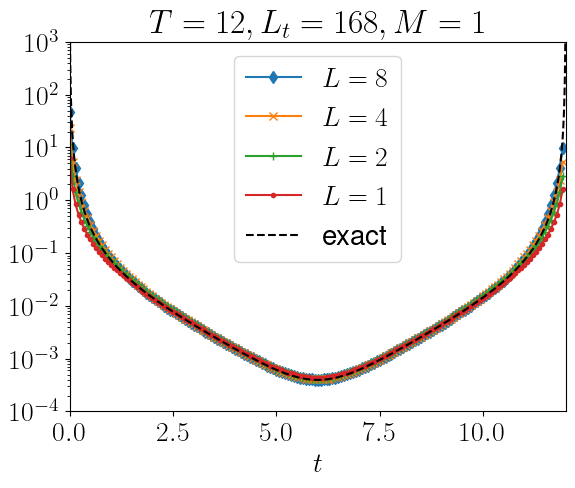

In [7]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l8_1, label="$L=8$", marker='d' )
plt.plot( xx, l4_1, label="$L=4$", marker='x' )
plt.plot( xx, l2_1, label="$L=2$", marker='+' )
plt.plot( xx, l1_1, label="$L=1$", marker='.' )
# plt.plot( xx, l12_1, label="$L=16$" )

xx=T * np.arange(10*Nt)/(10*Nt)

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$T=12, L_t="+str(Nt)+", M = 1$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e3)
plt.legend()

plt.savefig("prop_ov.pdf", bbox_inches="tight")

In [8]:
def Gt( t, nmax, T ):
    res = 0.0
    for n in range(nmax):
        res += (n+1.0) * ( np.exp( -(n+1.0)*t ) + np.exp( -(n+1.0)*(T-t) ) )
    res /= 4.0*np.pi
    return res

In [9]:
ts=T*np.arange(100)/100
Gts = np.array([Gt( t, 10, T ) for t in ts])

In [10]:
def fitter( t, z ):
    return np.log( z * Gt(t, nmax, T) )

In [11]:
xx=T * np.arange(Nt)/Nt

In [12]:
xx

array([ 0.        ,  0.07142857,  0.14285714,  0.21428571,  0.28571429,
        0.35714286,  0.42857143,  0.5       ,  0.57142857,  0.64285714,
        0.71428571,  0.78571429,  0.85714286,  0.92857143,  1.        ,
        1.07142857,  1.14285714,  1.21428571,  1.28571429,  1.35714286,
        1.42857143,  1.5       ,  1.57142857,  1.64285714,  1.71428571,
        1.78571429,  1.85714286,  1.92857143,  2.        ,  2.07142857,
        2.14285714,  2.21428571,  2.28571429,  2.35714286,  2.42857143,
        2.5       ,  2.57142857,  2.64285714,  2.71428571,  2.78571429,
        2.85714286,  2.92857143,  3.        ,  3.07142857,  3.14285714,
        3.21428571,  3.28571429,  3.35714286,  3.42857143,  3.5       ,
        3.57142857,  3.64285714,  3.71428571,  3.78571429,  3.85714286,
        3.92857143,  4.        ,  4.07142857,  4.14285714,  4.21428571,
        4.28571429,  4.35714286,  4.42857143,  4.5       ,  4.57142857,
        4.64285714,  4.71428571,  4.78571429,  4.85714286,  4.92

In [36]:
yy = l1_1

In [37]:
l1_1.shape[0]

168

In [38]:
for nmax in np.arange(1, 100):
    opt = sp.optimize.curve_fit( fitter, xx, np.log(beta*yy), full_output=True, absolute_sigma=True, p0=1 )
    diff = np.sum( opt[2]['fvec']**2 )
    print(nmax, diff/(l1_1.shape[0]-2), [opt[0][0], np.sqrt(opt[1][0,0])])

1 0.42477560204373094 [30.387051933717725, 2.3444113575582732]
2 0.16159259266796028 [23.9457142383432, 1.8474519322571468]
3 0.07548835992665608 [21.84346891738365, 1.6852602129516043]
4 0.042628532975251876 [20.790771229270135, 1.604042834928816]
5 0.03046746439440163 [20.156352310171954, 1.555096356560401]
6 0.02757163265104931 [19.731517861416727, 1.522319670497634]
7 0.029159008553799704 [19.42683348237842, 1.4988127599323615]
8 0.03299109616560081 [19.197484774126583, 1.4811181183208155]
9 0.03793708505592351 [19.01850686045225, 1.467309680968672]
10 0.043395361053845394 [18.87487973993187, 1.4562285876103094]
11 0.04903506283688223 [18.757020621785195, 1.4471355574543112]
12 0.05467120569220686 [18.658525995356797, 1.4395365445940829]
13 0.06020053574692675 [18.574953328565595, 1.4330887737703948]
14 0.06556693649473624 [18.503123228301945, 1.4275469499295765]
15 0.07074202829493383 [18.440700144089885, 1.4227309201270437]
16 0.07571393990039044 [18.385929746111145, 1.4185052795